# MVP: предиктивная аналитика для удержания клиентов

*В этом проекте строится MVP-модель прогнозирования оттока клиентов на основе открытого набора данных Customer Churn Dataset (Kaggle). Цель - оценить вероятность ухода клиента и выделить сегмент зоны риска для последующих маркетинговых действий по удержанию. В работе последовательно выполняются разведочный анализ данных, фиче-инжениринг, построение бейзлайна (логистическая регрессия) и улучшенной модели на CatBoost с последующей интерпретацией результатов.*

**!!! Все финальное решение содержится в пункте 6. Чтобы реализовать его, достаточно нажать play, в конце появятся визуализации, можно также скачать созданный файл под названием "churn_predictions.xlsx" из блока Output (если ноутбук открыт в Kaggle).**

Достаточно запустить ячейки только этого блока, чтобы MVP заработал и появился результат. Все остальные блоки кода - наша работа над MVP.

## 1. Загрузка датасета из облака Kaggle и просмотр стурктуры данных

In [1]:
import pandas as pd

file_path = "/kaggle/input/customer-churn-dataset/customer_churn_dataset-training-master.csv"
df = pd.read_csv(file_path)

df.shape          
df.head()         
df.info()         

target_col = "Churn"                  
df[target_col].value_counts(normalize=True) * 100  # Доли клиентов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


Churn
1.0    56.71072
0.0    43.28928
Name: proportion, dtype: float64

## 2. Разведочный анализ данных (EDA) и построение визуализаций

In [2]:
df.isna().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [3]:
df = df.dropna()
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

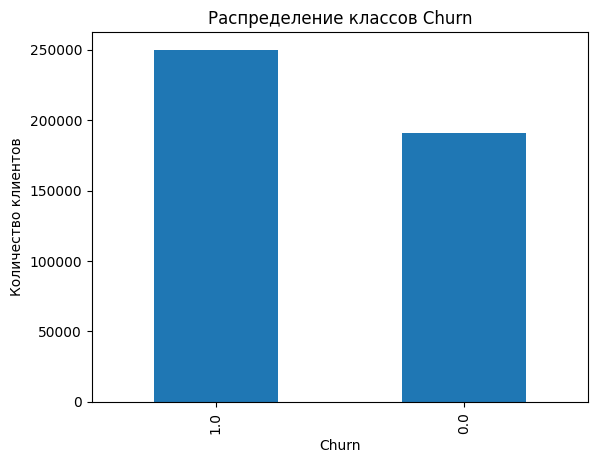

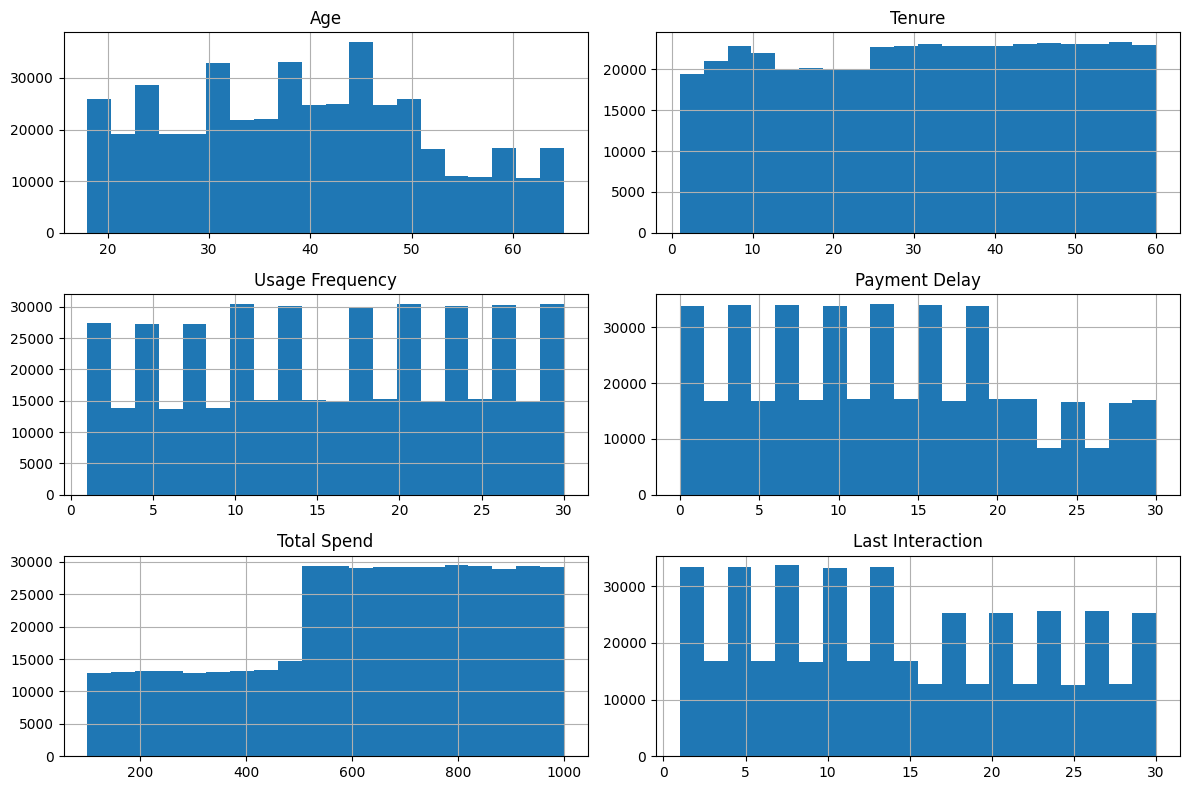

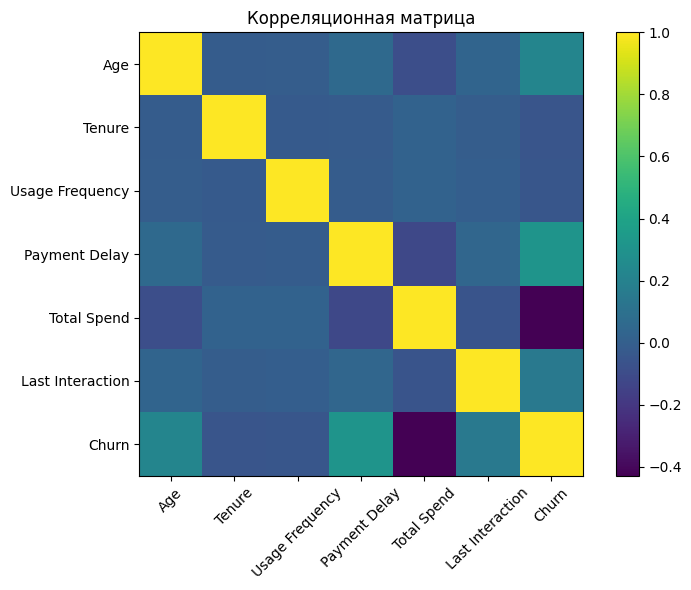

In [4]:
import matplotlib.pyplot as plt

%matplotlib inline

target_col = "Churn"

# Базовая статистика по числовым признакам
numeric_cols = ["Age", "Tenure", "Usage Frequency", "Payment Delay",
                "Total Spend", "Last Interaction"]

df[numeric_cols].describe()

# Доли клиентов (ушли или не ушли)
df[target_col].value_counts(normalize=True) * 100

df[target_col].value_counts().plot(kind="bar")
plt.title("Распределение классов Churn")
plt.xlabel("Churn")
plt.ylabel("Количество клиентов")
plt.show()

# Гистограммы по ключевым числовым признакам
df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Сравнение средних значений признаков по группам churn / non-churn
df.groupby(target_col)[numeric_cols].mean()

# Корреляции между числовыми переменными
corr_matrix = df[numeric_cols + [target_col]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Корреляционная матрица")
plt.colorbar()
plt.tight_layout()
plt.show()

Исходя из построенных визуализаций, можно сделать выводы:
1. Распределения числовых признаков в целом достаточно ровные, без ярко выраженных выбросов и сильной асимметрии - это подтверждает, что датасет уже обработан.

2. Большинство парных корреляций находятся в слабой зоне, что удобно для обучения моделей.

3. Наиболее заметная связь с оттоком - у **Total Spend**: чем ниже совокупные траты клиента, тем выше вероятность его ухода (умеренно отрицательная корреляция с Churn).

4. Возраст и стаж (Age, Tenure) почти не связаны с оттоком, поэтому вряд ли они будут ключевыми факторами риска без учёта других признаков.

## 3. Feature engeneering

In [5]:
df["avg_monthly_spend"] = df["Total Spend"] / df["Tenure"].replace(0, 1)
# У клиента может быть большой Total Spend просто потому, что он давно с нами. Но нам важнее, сколько он приносит в среднем за период

df["engagement_index"] = df["Usage Frequency"] / (df["Last Interaction"] + 1)
# Сочетание частоты использования и давности последнего взаимодействия. Клиент с высокой частотой и недавним контактом живой, 
# а с низкой частотой и давней активностью - кандидат на отток

df["late_payer_flag"] = (df["Payment Delay"] > 10).astype(int)
# Значительные задержки платежей часто предшествуют оттоку - человек уже теряет интерес к сервису

### Визуализация новых признаков

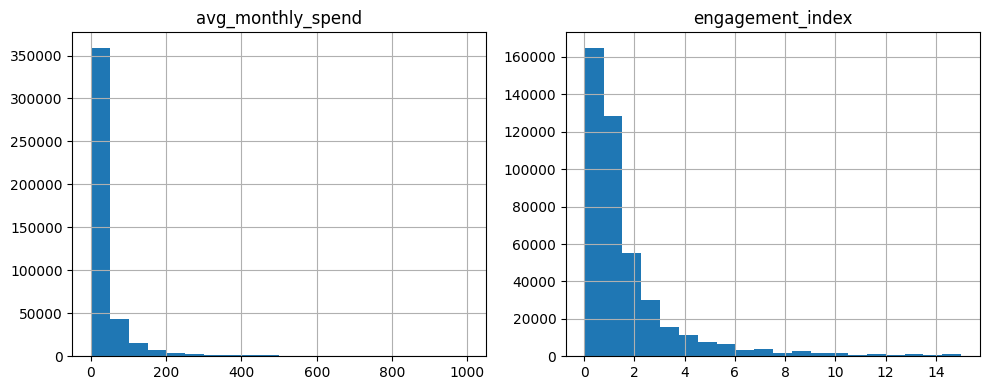

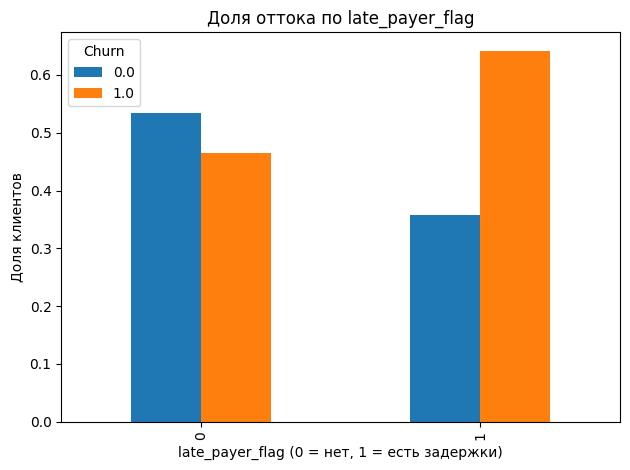

In [6]:
df[["avg_monthly_spend", "engagement_index"]].hist(bins=20, figsize=(10, 4))
plt.tight_layout()
plt.show()

# отток по должникам
pd.crosstab(df["late_payer_flag"], df["Churn"], normalize="index").plot(kind="bar")
plt.title("Доля оттока по late_payer_flag")
plt.xlabel("late_payer_flag (0 = нет, 1 = есть задержки)")
plt.ylabel("Доля клиентов")
plt.tight_layout()
plt.show()

Выводы:
1. Для avg_monthly_spend и engagement_index основная масса клиентов сконцентрирована на низких значениях, а небольшая группа даёт очень высокие значения - то есть есть заметная группа ценных и сильно вовлечённых пользователей на фоне большого числа слабых клиентов. Эти признаки хорошо дифференцируют клиентов по ценности и активности.

2. По late_payer_flag видно, что среди клиентов с задержками платежей доля оттока существенно выше, чем среди клиентов без задержек. Это делает признак сильным кандидатом на ключевой фактор риска и показывает, что хронические должники - логичная целевая группа для превентивных мер по удержанию.

## 4. Построение логистической регрессии в качестве бейзлайна

*Логистическая регрессия - это модель для бинарной классификации (0 - клиент не ушел, 1 - ушел), которая по набору признаков оценивает вероятность принадлежности объекта к классу 1, то есть вероятность, что клиент уйдет.*

Мы берём логистическую регрессию как базовую модель, потому что она:
* проста в настройке и быстра в обучении;
* дает понимание, какие признаки увеличивают/уменьшают риск оттока;
* служит хорошей отправной точкой, с которой удобно сравнивать более сложные модели (CatBoost).

In [7]:
from sklearn.model_selection import train_test_split # Для разделения на обучающие и тестовые данные
from sklearn.linear_model import LogisticRegression # Импортируем саму модель
from sklearn.metrics import accuracy_score, confusion_matrix # Неоьбходимые для оценки метрики

target_col = "Churn"

feature_cols = [
    "Age", "Tenure", "Usage Frequency", "Payment Delay",
    "Total Spend", "Last Interaction",
    "avg_monthly_spend", "engagement_index", "late_payer_flag"
]

X = df[feature_cols]
y = df[target_col]

# Делим на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)


y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

pd.Series(logreg.coef_[0], index=feature_cols).sort_values(ascending=False)

Payment Delay        0.169572
Last Interaction     0.044369
Age                  0.041894
engagement_index     0.039349
avg_monthly_spend    0.000403
Total Spend         -0.004696
Tenure              -0.005397
Usage Frequency     -0.015917
late_payer_flag     -1.412094
dtype: float64

In [8]:
accuracy_score(y_test ,y_pred)

0.7497362958930212

Выводы: 

1. Payment Delay (0.17) - чем больше задержки по платежам, тем выше риск, что клиент уйдёт. Это наиболее сильный положительный фактор в модели.

2. Last Interaction, Age, engagement_index (небольшие плюсы) - более давнее последнее взаимодействие, более старший возраст и низкая вовлечённость в целом связаны с чуть более высоким риском оттока, но влияние слабое.

3. Total Spend, Tenure, Usage Frequency (маленькие минусы) - чем дольше клиент с нами, чем больше он тратит и чаще пользуется сервисом, тем чуть ниже вероятность оттока.

4. late_payer_flag (-1.41) - формально модель показывает сильный минус, но этот признак почти дублирует Payment Delay, поэтому из-за сильной связи между ними коэффициенты могут быть такими высокими. Для интерпретации разумнее опираться на сам Payment Delay, а бинарный флаг использовать скорее как техническую фичу, а не как основной управленческий вывод

5. Точность модели составила 75%

## 5. Построение основной модели (Catboost)

*CatBoost — это модель, которая по шагам учится на предыдущих ошибках в и в итоге очень хорошо ловит сложные зависимости в данных.*

Почему мы её берём как основную модель:

* отлично работает с табличными данными, как у нас;
* умеет учитывать нелинейные связи (например, комбинацию траты × срок обслуживания);
* обычно даёт лучшее качество, чем простые модели вроде логистической регрессии;
* при этом её ещё можно интерпретировать через важность признаков — понятно, какие факторы больше всего влияют на риск оттока.

In [9]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

cat_model.fit(X_train, y_train)

y_pred = cat_model.predict(X_test)
y_proba = cat_model.predict_proba(X_test)[:, 1]

feature_importances = pd.Series(
    cat_model.get_feature_importance(),
    index=feature_cols
).sort_values(ascending=False)

feature_importances

Total Spend          37.762422
Age                  26.058803
Payment Delay        24.332904
Tenure                6.577738
Usage Frequency       3.711277
Last Interaction      0.570267
avg_monthly_spend     0.562211
engagement_index      0.392120
late_payer_flag       0.032258
dtype: float64

In [10]:
accuracy_score(y_test ,y_pred)

0.8804427960574818

Кратко по результатам:

1. Качество модели сильно выросло
   Accuracy вырос примерно с 0.75 у логрегрессии до 0.88 у CatBoost, то есть модель заметно лучше ловит закономерности в данных. Это хороший аргумент, почему его можно считать основной рабочей моделью.

2. Главные факторы риска по CatBoost:

   * Total Spend (~38) - самый важный признак: уровень совокупных трат сильнее всего связан с тем, уйдёт клиент или нет.
   * Age (~26) – возраст тоже даёт серьёзный вклад.
   * Payment Delay (~24) – задержки платежей остаются ключевым сигналом возможного оттока.
   * Далее по значимости: Tenure, Usage Frequency, остальные признаки уже дают гораздо меньший вклад.

3. Новые признаки почти не играют роли.
   `avg_monthly_spend`, `engagement_index` и `late_payer_flag` имеют очень маленькую важность, то есть CatBoost в основном опирается на исходные признаки. Их не будем использовать в финальном решении ниже.


## 6. Упаковка полного решения с сохранением результатов и построением дашборда

### Техническая реализация с сохранением эксель файла с предсказаниями

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("/kaggle/input/customer-churn-dataset/customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("/kaggle/input/customer-churn-dataset/customer_churn_dataset-testing-master.csv") # На этих данных будет предсказание

target_col = "Churn"

# Подготовка данных
def prepare_df(data, is_train=True):
    base_cols = ["Age", "Tenure", "Usage Frequency",
                 "Payment Delay", "Total Spend", "Last Interaction"]

    cols_to_check = base_cols + ([target_col] if is_train else [])
    data = data.dropna(subset=cols_to_check).copy()

    if is_train:
        data[target_col] = data[target_col].astype(int)

    return data

train_df = prepare_df(train_df, is_train=True)
test_df_prepared = prepare_df(test_df, is_train=False)

# Обучение CatBoost
feature_cols = [
    "Age", "Tenure", "Usage Frequency", "Payment Delay",
    "Total Spend", "Last Interaction"
]

X = train_df[feature_cols]
y = train_df[target_col]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

cat_model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

# Предсказания на тестовом датасете
test_X = test_df_prepared[feature_cols]
test_df_prepared["churn_proba"] = cat_model.predict_proba(test_X)[:, 1]
test_df_prepared["churn_flag"] = (test_df_prepared["churn_proba"] >= 0.5).astype(int)

# Выбираем важные признаки + таргет и сохраняем в Excel
important_cols = [
    "CustomerID", "Total Spend", "Age", "Payment Delay", "Tenure",
    "Usage Frequency", "churn_proba", "churn_flag"
]

# Файл churn_predictions.xlsx будет содержать только выбранные важные признаки и две целевые колонки: 
# вероятность оттока (churn_proba) и флаг «в зоне риска» (churn_flag), если вероятность больше 0.5

output_cols = [col for col in important_cols if col in test_df_prepared.columns]

test_df_prepared[output_cols].to_excel("churn_predictions.xlsx", index=False)

### Построение дашборда

#### Формирование сегмента клиентов в зоне риска (которые могут уйти)

In [12]:
%matplotlib inline

df_pred = pd.read_excel("/kaggle/working/churn_predictions.xlsx") # Путь к эксель файлу, полученному на предыдущем шаге

def risk_bucket(p):
    if p >= 0.8:
        return "Высокий"
    elif p >= 0.5:
        return "Средний"
    else:
        return "Низкий"

df_pred["risk_level"] = df_pred["churn_proba"].apply(risk_bucket)

risk_df = df_pred[df_pred["risk_level"].isin(["Средний", "Высокий"])]

total_clients = len(df_pred)
risk_clients = len(risk_df)
risk_share = risk_clients / total_clients

total_clients, risk_clients, round(risk_share * 100, 2)

(64374, 51938, 80.68)

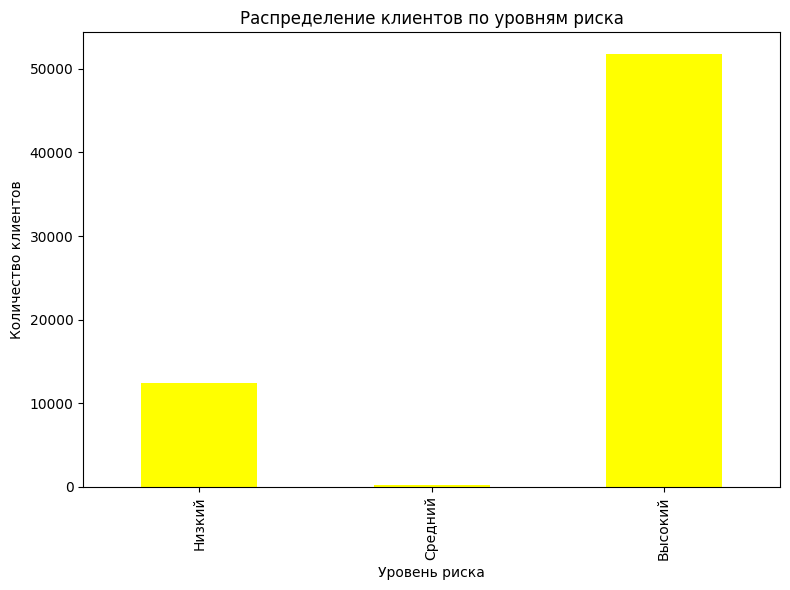

In [13]:
# График 1. Распределение клиентов по уровням риска
risk_counts = df_pred["risk_level"].value_counts().reindex(["Низкий", "Средний", "Высокий"])

plt.figure(figsize=(8, 6))
risk_counts.plot(kind="bar", color='yellow')
plt.title("Распределение клиентов по уровням риска")
plt.xlabel("Уровень риска")
plt.ylabel("Количество клиентов")
plt.tight_layout()
plt.show()

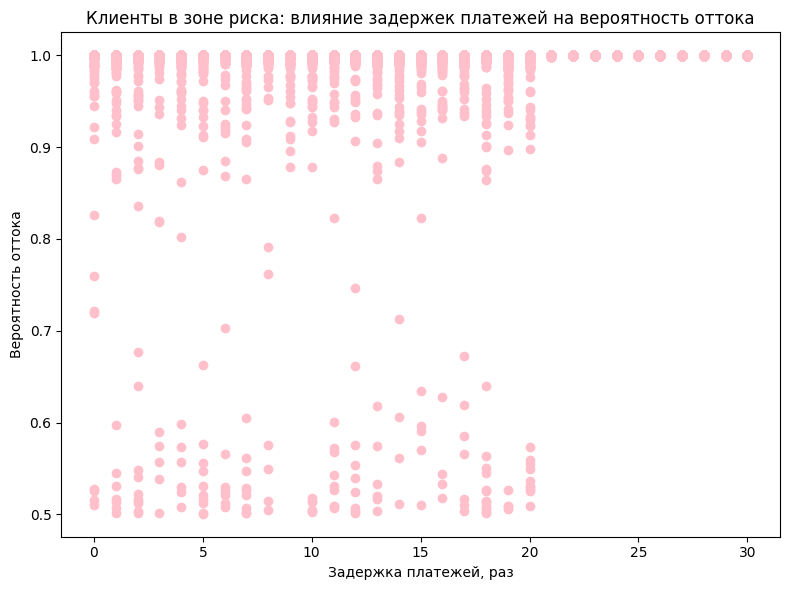

In [14]:
# График 2. Вероятность оттока по ключевым признакам
plt.figure(figsize=(8, 6))
plt.scatter(risk_df["Payment Delay"], risk_df["churn_proba"], color = 'pink')
plt.xlabel("Задержка платежей, раз")
plt.ylabel("Вероятность оттока")
plt.title("Клиенты в зоне риска: влияние задержек платежей на вероятность оттока")
plt.tight_layout()
plt.show()

In [15]:
# Таблица: топ-5 клиентов с самым высоким риском
risk_df.sort_values("churn_proba", ascending=False).head(5)

,CustomerID,Total Spend,Age,Payment Delay,Tenure,Usage Frequency,churn_proba,churn_flag,risk_level
55620,55621,746,57,13,14,4,0.999999,1,Высокий
55624,55625,715,59,8,23,2,0.999999,1,Высокий
63690,63691,750,59,16,23,5,0.999999,1,Высокий
30430,30431,761,58,14,21,6,0.999999,1,Высокий
3843,3844,770,61,10,23,3,0.999999,1,Высокий


In [16]:
# Таблица: топ-5 клиентов с самым низким риском
risk_df.sort_values("churn_proba").head(5)

,CustomerID,Total Spend,Age,Payment Delay,Tenure,Usage Frequency,churn_proba,churn_flag,risk_level
27848,27849,817,18,5,54,8,0.500656,1,Средний
15381,15382,655,18,3,30,19,0.501081,1,Средний
32860,32861,675,19,7,21,27,0.501151,1,Средний
31388,31389,992,22,7,39,3,0.501156,1,Средний
32204,32205,989,25,5,40,4,0.501450,1,Средний


## 7. Заключение по технической части

В рамках технической части проекта был построен полное MVP предиктивной модели оттока. На основе датасета Customer Churn Dataset проведены первичный анализ и EDA, построены базовые визуализации и несколько простых производных признаков. Далее была обучена логистическая регрессия как бейзлайн-модель с точностью около 0.75.

Затем в качестве основной модели был применён CatBoost, лучше подходящий для табличных данных с нелинейными связями. Он показал существенно более высокое качество (accuracy ~0.88) и позволил выделить ключевые факторы риска оттока: совокупные траты клиента, возраст, задержки платежей, стаж и частоту использования сервиса. Полученные скоринги могут быть напрямую использованы для выделения сегмента клиентов в зоне риска и дальнейшей визуализации.

## 8. Формирование рекомендаций

Для клиентов с высоким риском и высокой ценностью (высокий Total Spend, большой срок обслуживания) логично применять персональные предложения: продление текущего тарифа на льготных условиях, индивидуальные скидки на любимые продукты или услуги, подарочные месяцы подписки, доступ к премиальному функционалу. Важно сопровождать это персональной коммуникацией: звонок или письмо от менеджера с объяснением, что условия предоставлены именно им как лояльным клиентам. Для части таких клиентов стоит настроить ранний звонок при росте задержек платежей или снижении частоты использования сервиса, чтобы разобраться в причинах недовольства и предложить решение (упрощение тарифа, пауза в обслуживании, рассрочка платежа).

Для клиентов со средним риском и средней ценностью имеет смысл запускать автоматические триггерные кампании: e-mail и push с напоминаниями об услуге, подборкой релевантного контента, рекомендациями по более подходящему тарифу без переплат. Можно тестировать мягкие мотивации: небольшие разовые бонусы, промокоды при возвращении в сервис, участие в программе лояльности с накоплением баллов за активность. Для клиентов с низким риском основная задача — поддерживать вовлеченность: регулярные, но не навязчивые коммуникации, полезный контент, ранний доступ к новинкам. Отдельным направлением стоит работать с клиентами, у которых часто возникают задержки платежей: предложить им более удобные способы оплаты, напоминания за несколько дней до списания, возможность переноса даты списания, чтобы убрать финансовые и организационные барьеры, которые подталкивают к оттоку.